# Step 01: Test geometry.py

In [2]:
%load_ext autoreload
%autoreload 2
from multisensor_splat.geometry import *
from multisensor_splat.synthetic import *
from multisensor_splat.visualization import *
from multisensor_splat.data.kitti import *
import numpy as np

## Test homogeneous functions

In [3]:
pts = np.array([[1, 2, 3], 
                [1, 1, 1]])

pts_h = to_homogeneous(pts)
pts_back = from_homogeneous(pts_h)

pts, pts_h, pts_back


(array([[1, 2, 3],
        [1, 1, 1]]),
 array([[1, 2, 3, 1],
        [1, 1, 1, 1]]),
 array([[1., 2., 3.],
        [1., 1., 1.]]))

## Test transformations

In [4]:
theta = np.deg2rad(30)
R = np.array([[np.cos(theta), -np.sin(theta), 0],
              [np.sin(theta),  np.cos(theta), 0],
              [0,              0,             1]])
t = np.array([1, 2, 3])

T = make_transform(R, t)
T

array([[ 0.8660254, -0.5      ,  0.       ,  1.       ],
       [ 0.5      ,  0.8660254,  0.       ,  2.       ],
       [ 0.       ,  0.       ,  1.       ,  3.       ],
       [ 0.       ,  0.       ,  0.       ,  1.       ]])

In [5]:
T_inv = invert_transform(T)
T_inv

array([[ 0.8660254 ,  0.5       ,  0.        , -1.8660254 ],
       [-0.5       ,  0.8660254 ,  0.        , -1.23205081],
       [ 0.        ,  0.        ,  1.        , -3.        ],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [6]:
pts_transformed = transform_points(T, pts)
pts_back = transform_points(T_inv, pts_transformed)

pts, pts_transformed, pts_back

(array([[1, 2, 3],
        [1, 1, 1]]),
 array([[0.8660254 , 4.23205081, 6.        ],
        [1.3660254 , 3.3660254 , 4.        ]]),
 array([[1., 2., 3.],
        [1., 1., 1.]]))

## Test projection

In [7]:
fx, fy, cx, cy = 500.0, 400.0, 320.0, 240.0
K = make_intrinsics(fx, fy, cx, cy)

points_cam = np.array([
    [ 0.0,   0.0,  1.0],   # on optical axis
    [ 0.0,   0.0,  5.0],   # on optical axis, farther away
    [ 1.0,   0.0,  1.0],   # pure +x offset
    [ 0.0,   1.0,  1.0],   # pure +y offset (down)
    [ 1.0,   1.0,  2.0],   # diagonal, z != 1
    [ 2.0,   2.0,  4.0],   # same ray as above, scaled by 2
    [-1.0,  -1.0,  2.0],   # negative x and y (up-left)
    [ 0.5, -0.25,  1.0],   # fractional, mixed signs
    [ 3.0,   1.5,  6.0],   # non-unit depth, non-trivial ratios
])

expected_px = np.array([
    [320.0, 240.0],
    [320.0, 240.0],
    [820.0, 240.0],
    [320.0, 640.0],
    [570.0, 440.0],
    [570.0, 440.0],
    [ 70.0,  40.0],
    [570.0, 140.0],
    [570.0, 340.0],
])

In [8]:
unproject(expected_px, points_cam[:, -1:], K)


array([[[ 0.  ,  0.  ,  1.  ],
        [ 0.  ,  0.  ,  1.  ],
        [ 1.  ,  0.  ,  1.  ],
        [ 0.  ,  1.  ,  1.  ],
        [ 0.5 ,  0.5 ,  1.  ],
        [ 0.5 ,  0.5 ,  1.  ],
        [-0.5 , -0.5 ,  1.  ],
        [ 0.5 , -0.25,  1.  ],
        [ 0.5 ,  0.25,  1.  ]],

       [[ 0.  ,  0.  ,  5.  ],
        [ 0.  ,  0.  ,  5.  ],
        [ 5.  ,  0.  ,  5.  ],
        [ 0.  ,  5.  ,  5.  ],
        [ 2.5 ,  2.5 ,  5.  ],
        [ 2.5 ,  2.5 ,  5.  ],
        [-2.5 , -2.5 ,  5.  ],
        [ 2.5 , -1.25,  5.  ],
        [ 2.5 ,  1.25,  5.  ]],

       [[ 0.  ,  0.  ,  1.  ],
        [ 0.  ,  0.  ,  1.  ],
        [ 1.  ,  0.  ,  1.  ],
        [ 0.  ,  1.  ,  1.  ],
        [ 0.5 ,  0.5 ,  1.  ],
        [ 0.5 ,  0.5 ,  1.  ],
        [-0.5 , -0.5 ,  1.  ],
        [ 0.5 , -0.25,  1.  ],
        [ 0.5 ,  0.25,  1.  ]],

       [[ 0.  ,  0.  ,  1.  ],
        [ 0.  ,  0.  ,  1.  ],
        [ 1.  ,  0.  ,  1.  ],
        [ 0.  ,  1.  ,  1.  ],
        [ 0.5 ,  0.5 ,  1.  ],
  

In [9]:
make_ground_grid(1, 1)

array([[-1., -1.,  0.],
       [-1.,  0.,  0.],
       [-1.,  1.,  0.],
       [ 0., -1.,  0.],
       [ 0.,  0.,  0.],
       [ 0.,  1.,  0.],
       [ 1., -1.,  0.],
       [ 1.,  0.,  0.],
       [ 1.,  1.,  0.]])

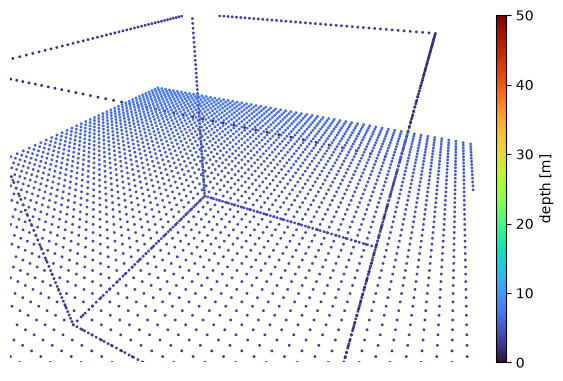

In [10]:
width, height = 640, 480
image = np.ones((height, width, 3), dtype=float)
pts_world = make_cube(np.array([0., 0., 1.]), 2, 50)
pts_world = np.vstack([pts_world, make_ground_grid(40, 0.1, 0)])
T_world_cam = look_at(np.array([2., 1., 2.5]), np.array([0., 0., 1.]))
T_cam_world = invert_transform(T_world_cam)
points_cam = transform_points(T_cam_world, pts_world)
uv, depth = project(points_cam, make_intrinsics(500, 500, 320, 240))

ax = plot_projection(image, uv, depth)

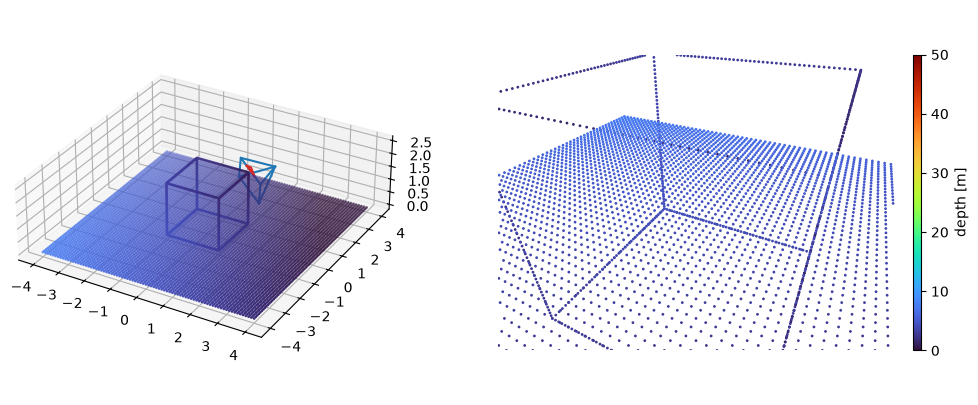

In [11]:
fig = plt.figure(figsize=(12, 5))
ax3d = fig.add_subplot(1, 2, 1, projection="3d")
ax2d = fig.add_subplot(1, 2, 2)

# Scene (cube + ground), colored by depth like the 2D projection
ax3d.scatter(pts_world[:, 0], pts_world[:, 1], pts_world[:, 2],
             c=depth[:, 0], s=1, cmap="turbo", vmin=0, vmax=50)
draw_camera_frustum(ax3d, T_world_cam, K, width, height)
ax3d.set_aspect("equal")

ax = plot_projection(image, uv, depth, ax2d)
plt.show()